In [2]:
import pytorch3d.structures
import pytorch3d.io
import pytorch3d.renderer

import torch
import numpy
import imageio
from matplotlib import pyplot as plt
import pickle

In [3]:
file = open("data/rgbd_data.pkl", "rb")
pkl_file = pickle.load(file)
file.close()

In [4]:
pkl_file

{'rgb1': array([[[0.81960785, 0.8039216 , 0.80784315],
         [0.81960785, 0.8039216 , 0.80784315],
         [0.8187211 , 0.8030349 , 0.8069564 ],
         ...,
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ]],
 
        [[0.81960785, 0.8039216 , 0.80784315],
         [0.81960785, 0.8039215 , 0.80784315],
         [0.8182827 , 0.80259645, 0.806518  ],
         ...,
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ]],
 
        [[0.81828433, 0.802598  , 0.8065196 ],
         [0.8196078 , 0.8039216 , 0.80784315],
         [0.8174043 , 0.80171794, 0.80563956],
         ...,
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ]],
 
        ...,
 
        [[0.6610104 , 0.20610838, 0.2806182 ],
         [0.6588363 , 0.20393431,

In [50]:
points = torch.Tensor(pkl_file['rgb1'][0])
rgb = torch.Tensor(pkl_file['rgb1'][0])
point_cloud = pytorch3d.structures.Pointclouds(points=points.unsqueeze(0), features=rgb.unsqueeze(0))

In [51]:
# Create renderer

cameras1 = pkl_file['cameras1']
raster_settings = pytorch3d.renderer.PointsRasterizationSettings(
    image_size=500,
    points_per_pixel=3
)

rasterizer = pytorch3d.renderer.PointsRasterizer(cameras=cameras1, raster_settings=raster_settings)
renderer  = pytorch3d.renderer.PointsRenderer(
    rasterizer=rasterizer,
    compositor=pytorch3d.renderer.AlphaCompositor()

)

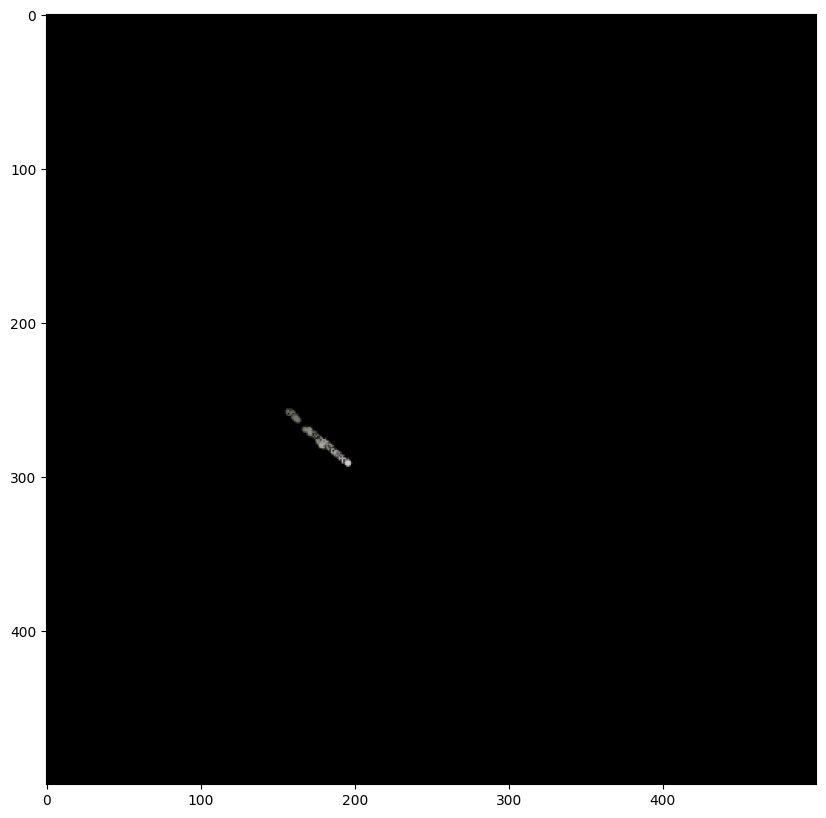

In [52]:
rend = renderer(point_cloud)
plt.figure(figsize=(10, 10))
plt.imshow(rend[0, ..., :3].numpy())

In [49]:
pkl_file['rgb1'][0].shape

(800, 3)

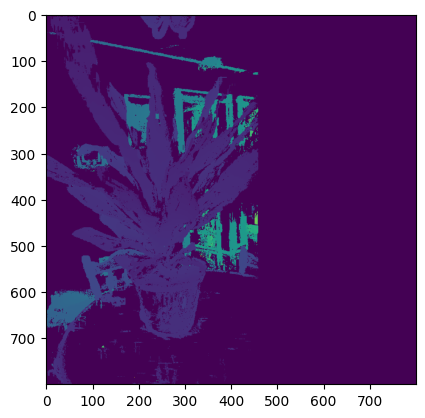

In [61]:
plt.imshow(pkl_file['depth2'])